Figure S1: Cross-mappability of clusters.  A Histogram of the number of genes in each cluster with more than 100 cross-mappable 75-mers. B Fraction of gene clusters with at least one significant QTL for clusters with at least one cross-mappable gene pair or with no cross mappable gene pairs. P-value from independent t-test. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import ttest_rel 



from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 


%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# load in clusters
clusters = load_across_tissues(config, load_clusters_annotated)
# load in pcs
pcs = load_across_tissues(config, load_pc)

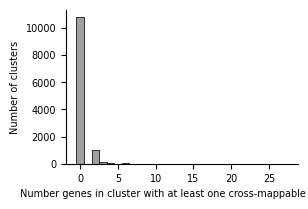

In [ ]:
fig, ax = plt.subplots(figsize=(3,2))
sns.histplot(clusters, x='num_cross_map', 
             discrete=True, color='grey')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("Number genes in cluster with at least one cross-mappable XX-mer")
ax.set_ylabel("Number of clusters")
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s1_a.pdf", transparent=True)

plt.show()


In [ ]:
pcs['has_cross_map'] = pcs['cluster_id'].isin(clusters[clusters['has_cross_map']]['cluster_id'])
pc_cs_by_cross_map = pcs.groupby(['tissue_id', 'has_cross_map']).agg({'has_cs':'mean'}).reset_index()

/local/scratch/klawren/slrmtmp.48323884/ipykernel_16676/473593937.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(pc_cs_by_cross_map, x='has_cross_map', y='has_cs',palette=['white', 'grey'], ax=ax)


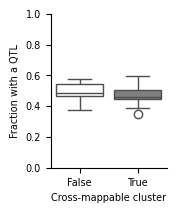

In [ ]:
fig, ax = plt.subplots(figsize=(1.5,2))

#sns.swarmplot(pc_cs_by_cross_map, x='has_cross_map', y='has_cs', ax=ax, color='k')
sns.boxplot(pc_cs_by_cross_map, x='has_cross_map', y='has_cs',palette=['white', 'grey'], ax=ax)
ax.set_ylim([0,1])

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Cross-mappable cluster')
ax.set_ylabel('Fraction with a QTL')

plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s1_b.pdf", transparent=True)
plt.show()


In [ ]:
ttest_rel(pc_cs_by_cross_map[pc_cs_by_cross_map['has_cross_map']]['has_cs'], pc_cs_by_cross_map[~pc_cs_by_cross_map['has_cross_map']]['has_cs'])

TtestResult(statistic=-1.0760115519741502, pvalue=0.30307999292190996, df=12)